In [1]:
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt

In [2]:
tickers = ['AAPL','MSFT','GOOG']
prices = yf.download(tickers, start = '2021-01-01', end = '2025-02-23')['Close']

[*********************100%***********************]  3 of 3 completed


In [3]:
daily_rets = prices.pct_change().dropna()
daily_rets

Ticker,AAPL,GOOG,MSFT
Date,,,
2021-01-05,0.012364,0.007337,0.000965
2021-01-06,-0.033661,-0.003234,-0.025929
2021-01-07,0.034123,0.029943,0.028457
2021-01-08,0.008631,0.011168,0.006093
2021-01-11,-0.023249,-0.022405,-0.009699
...,...,...,...
2025-02-14,0.012711,-0.005376,-0.005140
2025-02-18,-0.000532,-0.005726,0.002963
2025-02-19,0.001636,0.007158,0.012523


In [5]:
#Rendimientos individuales diarios
mean = daily_rets.mean()
mean

Ticker
AAPL    0.000780
GOOG    0.000907
MSFT    0.000776
dtype: float64

In [7]:
# Volaitilidad individual 
vol = daily_rets.std()
vol

Ticker
AAPL    0.016790
GOOG    0.019385
MSFT    0.016437
dtype: float64

In [9]:
# Tasa de riesgo
rf = 0.04 

# Anualización
rendimiento_anual = mean * 252
volatilidad_anual = vol * np.sqrt(252)

# Cálculo del Sharpe
sharpe_ratio = (rendimiento_anual - rf) / volatilidad_anual
sharpe_ratio

Ticker
AAPL    0.587857
GOOG    0.612703
MSFT    0.595701
dtype: float64

In [13]:
# Simulación montecarlo

num_portafolios = 10000
results = np.zeros((3 + len(tickers), num_portafolios))

cov_matrix = daily_rets.cov() * 252

for i in range(num_portafolios):
    #Pesos aleatorios
    weights = np.random.random(len(tickers))
    weights /= np.sum(weights)
    
    #Media y volatilidad
    portfolio_return = np.sum(weights * rendimiento_anual)
    portfolio_std_dev = np.sqrt(np.dot(weights.T, np.dot(cov_matrix, weights)))
    

    results[0,i] = portfolio_return
    results[1,i] = portfolio_std_dev
    results[2,i] = (portfolio_return - rf) / portfolio_std_dev
    results[3:,i] = weights

In [14]:
# Convertir a DataFrame para facilitar la graficación
columns = ['Retorno', 'Riesgo', 'Sharpe'] + tickers
df_sim = pd.DataFrame(results.T, columns=columns)
df_sim

,Retorno,Riesgo,Sharpe,AAPL,MSFT,GOOG
0,0.205255,0.247628,0.667352,0.122745,0.292004,0.585251
1,0.205945,0.243236,0.682238,0.267536,0.307366,0.425098
2,0.206504,0.245004,0.679596,0.215188,0.326226,0.458587
3,0.211822,0.251937,0.682004,0.396453,0.480009,0.123538
4,0.222419,0.282156,0.646518,0.155742,0.809168,0.035090
...,...,...,...,...,...,...
9995,0.206161,0.242543,0.685078,0.412715,0.308411,0.278874
9996,0.196374,0.243116,0.643206,0.627209,0.004693,0.368098
9997,0.199968,0.240784,0.664362,0.561432,0.115744,0.322824
9998,0.208187,0.245781,0.684297,0.263044,0.375264,0.361692


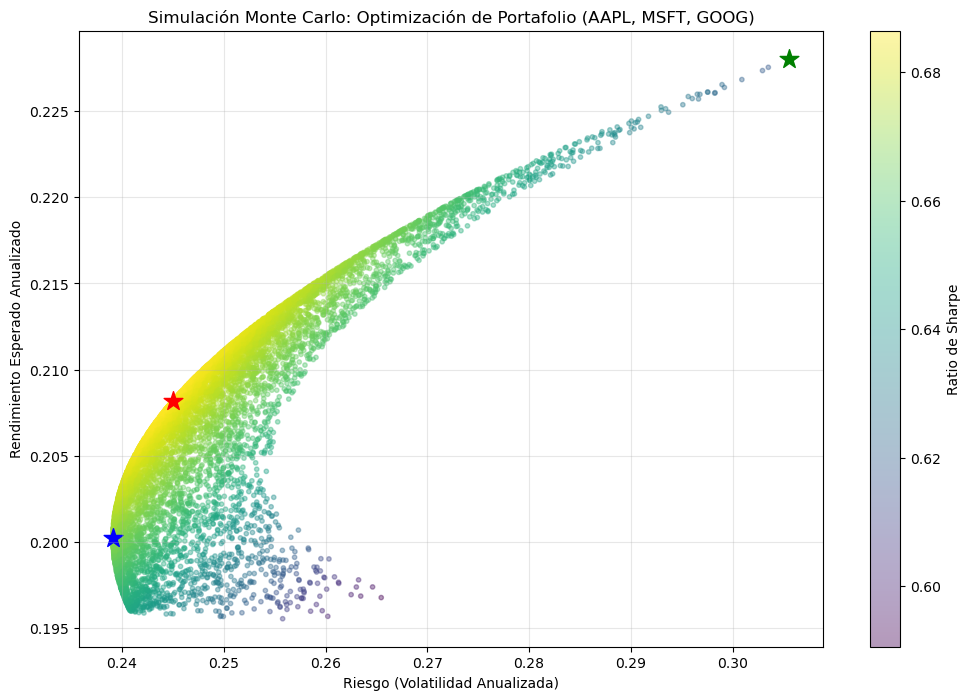

Portafolio con Mayor Sharpe:
 AAPL    0.351689
MSFT    0.371175
GOOG    0.277136
Name: 9646, dtype: float64

Portafolio de Menor Riesgo:
 AAPL    0.429876
MSFT    0.128091
GOOG    0.442033
Name: 1108, dtype: float64

Portafolio de Mayor Rendimiento:
 AAPL    0.006140
MSFT    0.984353
GOOG    0.009507
Name: 1685, dtype: float64


In [16]:

# Identificar portafolios clave
max_sharpe = df_sim.iloc[df_sim['Sharpe'].idxmax()]
min_vol = df_sim.iloc[df_sim['Riesgo'].idxmin()]
max_ret = df_sim.iloc[df_sim['Retorno'].idxmax()]

plt.figure(figsize=(12, 8))

# Dibujar todos los portafolios de la simulación
scatter = plt.scatter(df_sim['Riesgo'], df_sim['Retorno'], c=df_sim['Sharpe'], 
                     cmap='viridis', alpha=0.4, s=10)
plt.colorbar(scatter, label='Ratio de Sharpe')

# Marcar los puntos específicos solicitados
plt.scatter(max_sharpe['Riesgo'], max_sharpe['Retorno'], color='red', marker='*', s=200, label='Mayor Sharpe')
plt.scatter(min_vol['Riesgo'], min_vol['Retorno'], color='blue', marker='*', s=200, label='Menor Riesgo')
plt.scatter(max_ret['Riesgo'], max_ret['Retorno'], color='green', marker='*', s=200, label='Mayor Rendimiento')

plt.title('Simulación Monte Carlo: Optimización de Portafolio (' + ', '.join(tickers) + ')')
plt.xlabel('Riesgo (Volatilidad Anualizada)')
plt.ylabel('Rendimiento Esperado Anualizado')
plt.grid(True, alpha=0.3)
plt.show()

# Mostrar los pesos de los portafolios clave
print("Portafolio con Mayor Sharpe:\n", max_sharpe[tickers])
print("\nPortafolio de Menor Riesgo:\n", min_vol[tickers])
print("\nPortafolio de Mayor Rendimiento:\n", max_ret[tickers])

## Recomendación

Yo recomendaría que se fueran por el portafolio con el mayor ratio de sharpe, ya que primero es el que ofrece el mayor rendimiento por cada unidad de riesgo, es el que está mejor diversificado así que esto reduce el riesgo y por lo mismo siento que es el mas equilibrado, por lo menos para mi perfil